# Inflation - BCRP

In [6]:
import sys
from functools import reduce

import catppuccin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# TODO: create a visualization.py
plt.style.use(catppuccin.PALETTE.mocha.identifier)

# Importing inflation series

In [8]:
inflation_series = {
    "PN38705PM": "ipc",
    "PN38706PM": "ipc_sin_alimentos_bebidas",
    "PN38707PM": "ipc_sin_alimentos_energia",
    "PN38708PM": "ipc_subyacente",
    "PN38709PM": "ipc_transables",
    "PN38710PM": "ipc_no_transables",
    "PN38711PM": "ipc_no_transables_sin_alimentos_bebidas",
    "PN39445PM": "ipc_alimentos_bebidas",
    "PN39447PM": "ipc_subyacente_sin_alimentos_bebidas",
    "PN39521PM": "ipc_alimentos_energia",
    "PN39522PM": "ipc_no_subyacente",
    "PN39523PM": "ipc_importado",
}

In [9]:
build_bcrp_dataset = build_bcrp_dataset(inflation_series)

In [10]:
build_bcrp_dataset.head()

,period,ipc,ipc_sin_alimentos_bebidas,ipc_sin_alimentos_energia,ipc_subyacente,ipc_transables,ipc_no_transables,ipc_no_transables_sin_alimentos_bebidas,ipc_alimentos_bebidas,ipc_subyacente_sin_alimentos_bebidas,ipc_alimentos_energia,ipc_no_subyacente,ipc_importado
0,2026-04-01,120.21,115.98,117.34,118.15,116.66,121.78,118.11,126.57,113.85,123.76,124.58,109.39
1,2026-03-01,119.59,115.00,116.33,117.80,116.37,121.01,116.81,126.49,113.56,123.62,123.40,109.22
2,2026-02-01,116.81,112.18,113.97,116.91,114.34,117.90,113.76,123.76,112.70,120.32,116.61,104.39
3,2026-01-01,116.01,111.88,113.56,116.65,114.04,116.87,113.42,122.21,112.46,119.03,114.65,104.27
4,2025-12-01,115.89,111.85,113.52,116.49,113.93,116.76,113.44,121.97,112.37,118.83,114.63,104.11


In [ ]:
df_inflation = build_bcrp_dataset.sort_values("period").copy()

df_inflation["calculated_inflation"] = df_inflation["ipc"].pct_change() * 100
df_inflation[["period", "ipc", "calculated_inflation"]].tail(12)

,period,ipc,calculated_inflation
11,2025-05-01,115.51,-0.06
10,2025-06-01,115.66,0.13
9,2025-07-01,115.92,0.23
8,2025-08-01,115.59,-0.29
7,2025-09-01,115.60,0.01
6,2025-10-01,115.48,-0.10
5,2025-11-01,115.61,0.11
4,2025-12-01,115.89,0.24
3,2026-01-01,116.01,0.10
2,2026-02-01,116.81,0.69


In [25]:
df_real_analysis = df_inflation.copy()

np.random.seed(42)

df_real_analysis["nominal_amount"] = 1000 + np.cumsum(
    np.random.normal(40, 15, len(df_real_analysis))
)

df_real_analysis["real_amount"] = (
    df_real_analysis["nominal_amount"] / df_real_analysis["ipc"] * 100
)

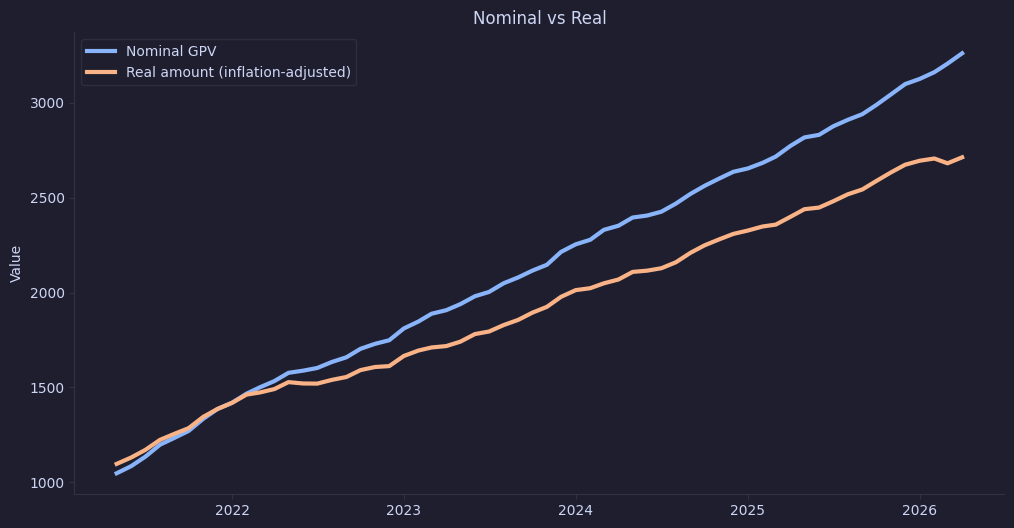

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_real_analysis["period"],
    df_real_analysis["nominal_amount"],
    label="Nominal GPV",
    linewidth=3,
)

ax.plot(
    df_real_analysis["period"],
    df_real_analysis["real_amount"],
    label="Real amount (inflation-adjusted)",
    linewidth=3,
)

ax.set_title("Nominal vs Real")
ax.set_ylabel("Value")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()